### Phase 2: Myopic revenue optimization

In this phase, we transition from understanding demand dynamics to actively optimizing pricing decisions. The objective is to identify, at each point in time, the price that maximizes expected revenue given the current observable market conditions.

Unlike Phase 1, which focused on structural validation, this stage adopts a **myopic perspective**: decisions are made to maximize immediate revenue without considering long-term effects or state transitions. This setting is equivalent to a contextual bandit problem, where the environment is treated as static conditional on the observed features.

Formally, at each time step $t$, the goal is to solve:

$$
p_t^* = \arg\max_p \; \mathbb{E}[\text{Revenue}_t \mid X_t, p]
$$

where:
- $p$ is the agent price,
- $X_t$ represents the current state (e.g., seasonality, competitor price),
- revenue is defined as:
$$
\text{Revenue}_t = (p - \text{cost}) \cdot \text{demand}(p, X_t)
$$

Using the demand model estimated in Phase 1 (e.g., via GAM), we approximate the conditional demand function and compute the price that maximizes expected revenue for each observed context.

This phase serves two key purposes:
- Validate that the learned demand model can be used for decision-making;
- Establish a baseline policy before introducing exploration-exploitation trade-offs and dynamic optimization.

By comparing the performance of this myopic policy against the exploratory baseline, we can quantify the gains from leveraging learned demand structure. This also provides a benchmark for more advanced approaches, such as contextual bandits and reinforcement learning, where future states and learning dynamics are explicitly considered.

In [110]:
import pickle
import random
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from functions import MarketPriors
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng()

In [111]:
df = pd.read_csv("data/phase_0.csv", parse_dates=["date"])
df = df[df["realized_demand"] > 0].copy()
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.tail()

(91, 7)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue
86,2025-03-28,134.345831,178.076805,0.000338,-0.057332,186.916376,8342.630120
87,2025-03-29,147.954683,175.893300,0.000176,0.011256,114.686989,7594.025603
88,2025-03-30,107.184015,167.187601,0.000089,-0.302732,79.644643,5337.627740
89,2025-03-31,125.116498,168.511787,0.000044,0.039753,195.373472,8987.674718
90,2025-04-01,146.459285,168.414978,1.126515,0.184123,267.082808,22891.788640


In [112]:
with open("models/phase_1.pkl", "rb") as f:
    model = pickle.load(f)

with open("models/phase_1_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

X = scaler.transform(df[["price_agent", "price_competitor", "season_signal"]])

c:\Users\Breno\Documents\Projects\data-science-examples\.venv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [118]:
def predict_demand(model, X_row, price_grid, feature_index_price=0):
    
    X_sim = np.tile(X_row, (len(price_grid), 1))
    X_sim[:, feature_index_price] = price_grid

    demand_pred = model.predict(X_sim)
    demand_pred = np.exp(demand_pred)
    demand_pred = np.clip(demand_pred, 1, 2500)
    
    return demand_pred

def compute_revenue(price_grid, demand_pred, unit_cost, fixed_cost):
    return ((price_grid - unit_cost) * demand_pred) - fixed_cost

def optimize_price(model, X_row, priors, price_grid):

    demand_pred = predict_demand(model, X_row, price_grid)
    
    price_raw = price_grid * scaler.scale_[0] + scaler.mean_[0]
    revenue = compute_revenue(price_raw, demand_pred, priors.unit_cost, priors.fixed_cost)
    
    idx = np.argmax(revenue)
    return price_raw[idx], revenue[idx]

In [128]:
priors = MarketPriors()
price_grid = np.linspace(priors.price_min, priors.price_max, 200)
price_grid = (price_grid - scaler.mean_[0]) / scaler.scale_[0]

optimal_prices = []
optimal_revenues = []

for i in range(len(X)):

    p_opt, r_opt = optimize_price(model, X[i], priors, price_grid)
    optimal_revenues.append(r_opt)
    optimal_prices.append(p_opt)

df["optimal_price"] = optimal_prices
df["optimal_revenue"] = optimal_revenues

In [129]:
print("Mean revenue uplift:", (df["optimal_revenue"] - df["revenue"]).mean().round(2))
print("Total revenue uplift:", (df["optimal_revenue"].sum() - df["revenue"].sum()).round(2))

Mean revenue uplift: 3576.22
Total revenue uplift: 325435.77


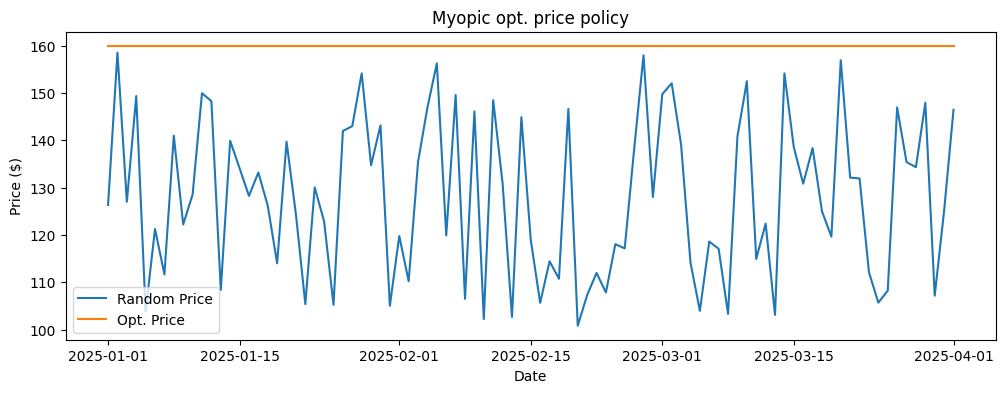

In [130]:
fig, ax = plt.subplots(figsize=(12, 4))
plt.plot(df["date"], df["price_agent"], label="Random Price")
plt.plot(df["date"], df["optimal_price"], label="Opt. Price")

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
plt.title("Myopic opt. price policy")

plt.legend()
plt.show()

#### Flat optimization explanation

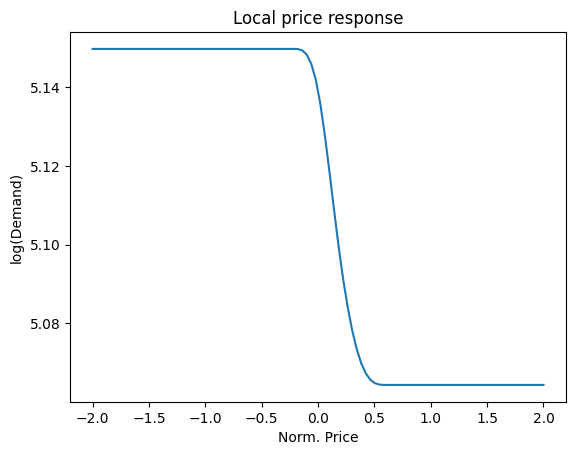

std: 0.04090945568584493


In [132]:
i = 0

X_row = X[i]
grid = np.linspace(-2, 2, 100)  # scaled price

X_sim = np.tile(X_row, (100, 1))
X_sim[:, 0] = grid

pred = model.predict(X_sim)

fig, ax = plt.subplots()
plt.plot(grid, pred)

ax.set_xlabel("Norm. Price")
ax.set_ylabel("log(Demand)")

plt.title("Local price response")
plt.show()

print("std:", np.std(pred))

The myopic optimization results showed that the optimal price frequently converges to the upper bound of the allowed price range. This behavior is not caused by an error in the optimization procedure itself, but rather by the **local behavior of the learned demand model**.

Although the partial dependence analysis indicated that price has a meaningful global effect on demand, further inspection of the local response revealed that this effect is concentrated within a **narrow region of the price space**. Outside this region, the model predicts demand to be nearly constant with respect to price.

As a consequence, for most observed states $X_t$, the demand function satisfies:

$$
\frac{\partial D(p, X_t)}{\partial p} \approx 0
$$

In these regions, revenue simplifies to approximately:

$$
R(p) \approx p \cdot D
$$

which is monotonically increasing in price. Therefore, the optimizer naturally selects the **maximum allowable price**, leading to a flat optimal pricing policy.

This outcome highlights an important limitation of the current modeling approach: while the model captures global elasticity, it lacks sufficient **local sensitivity** in many regions of the state space. This is likely due to a combination of smoothing in the GAM, monotonic constraints, and limited data coverage across the full price range.

In summary, the flat optimal price is not an economic result, but a consequence of the model being locally uninformative about price sensitivity. This reinforces the importance of ensuring that learned demand models exhibit meaningful gradients in the regions where optimization is performed.